In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
from pprint import pprint
# import pandas_ta
# import talib
import pickle
# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

import talib

# from pklib.strategy import *
from pklib.utilities import *
# from pklib.pkindicators import calculate_zigzag
from pklib.indicators import *

# from pklib.rl import *


In [2]:
import dotenv
import os

# Reload the variables in your '.env' file (override the existing variables)
dotenv.load_dotenv(".env", override=True)

# 'MY_VAR' is refreshed now
print('HIP_VISIBLE_DEVICES = ', os.environ.get('HIP_VISIBLE_DEVICES')) # MY_VAR = HELLO_BOB

HIP_VISIBLE_DEVICES =  0


In [3]:

import gymnasium as gym  # Use Gymnasium instead of gym
from gymnasium.spaces import Discrete, Box
from gymnasium import register

In [4]:
import collections
# import cv2
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

def plot_learning_curve(x, scores, epsilons, filename, lines=None):
    fig=plt.figure()
    ax=fig.add_subplot(111, label="1")
    ax2=fig.add_subplot(111, label="2", frame_on=False)

    ax.plot(x, epsilons, color="C0")
    ax.set_xlabel("Training Steps", color="C0")
    ax.set_ylabel("Epsilon", color="C0")
    ax.tick_params(axis='x', colors="C0")
    ax.tick_params(axis='y', colors="C0")

    N = len(scores)
    running_avg = np.empty(N)
    for t in range(N):
	    running_avg[t] = np.mean(scores[max(0, t-20):(t+1)])

    ax2.scatter(x, running_avg, color="C1")
    ax2.axes.get_xaxis().set_visible(False)
    ax2.yaxis.tick_right()
    ax2.set_ylabel('Score', color="C1")
    ax2.yaxis.set_label_position('right')
    ax2.tick_params(axis='y', colors="C1")

    if lines is not None:
        for line in lines:
            plt.axvline(x=line)

    plt.savefig(filename)

class RepeatActionAndMaxFrame(gym.Wrapper):
    """ modified from:
        https://github.com/PacktPublishing/Deep-Reinforcement-Learning-Hands-On/blob/master/Chapter06/lib/wrappers.py
    """
    def __init__(self, env=None, repeat=4):
        super(RepeatActionAndMaxFrame, self).__init__(env)
        self.repeat = repeat
        self.shape = env.observation_space.low.shape
        self.frame_buffer = np.zeros_like((2,self.shape))

    def step(self, action):
        t_reward = 0.0
        done = False
        for i in range(self.repeat):
            obs, reward, done, info = self.env.step(action)
            t_reward += reward
            idx = i % 2
            self.frame_buffer[idx] = obs
            if done:
                break

        max_frame = np.maximum(self.frame_buffer[0], self.frame_buffer[1])
        return max_frame, t_reward, done, info

    def reset(self):
        obs = self.env.reset()
        self.frame_buffer = np.zeros_like((2,self.shape))
        self.frame_buffer[0] = obs
        return obs

class PreprocessFrame(gym.ObservationWrapper):
    def __init__(self, shape, env=None):
        super(PreprocessFrame, self).__init__(env)
        self.shape=(shape[2], shape[0], shape[1])
        self.observation_space = gym.spaces.Box(low=0, high=1.0,
                                              shape=self.shape,dtype=np.float32)
    def observation(self, obs):
        new_frame = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        resized_screen = cv2.resize(new_frame, self.shape[1:],
                                    interpolation=cv2.INTER_AREA)

        new_obs = np.array(resized_screen, dtype=np.uint8).reshape(self.shape)
        new_obs = np.swapaxes(new_obs, 2,0)
        new_obs = new_obs / 255.0
        return new_obs

class StackFrames(gym.ObservationWrapper):
    def __init__(self, env, n_steps):
        super(StackFrames, self).__init__(env)
        self.observation_space = gym.spaces.Box(
                             env.observation_space.low.repeat(n_steps, axis=0),
                             env.observation_space.high.repeat(n_steps, axis=0),
                             dtype=np.float32)
        self.stack = collections.deque(maxlen=n_steps)

    def reset(self):
        self.stack.clear()
        observation = self.env.reset()
        for _ in range(self.stack.maxlen):
            self.stack.append(observation)

        return np.array(self.stack).reshape(self.observation_space.low.shape)

    def observation(self, observation):
        self.stack.append(observation)
        obs = np.array(self.stack).reshape(self.observation_space.low.shape)

        return obs

# def make_env(env_name, shape=(84,84,1), skip=4):
#     env = gym.make(env_name)
#     env = RepeatActionAndMaxFrame(env, skip)
#     env = PreprocessFrame(shape, env)
#     env = StackFrames(env, skip)

#     return env


In [5]:


def split_dataframes(dataframes, train_size=0.7):
    """
    Split the input dataframes into training and testing sets.

    Parameters:
    dataframes (list): List of pandas DataFrames to split.
    train_size (float): Proportion of the data to use for training (default is 0.7).

    Returns:
    tuple: (train_dfs, test_dfs) Lists of DataFrames for training and testing.
    """
    train_dfs = []
    test_dfs = []

    for df in dataframes:
        # Calculate the split index
        split_index = int(len(df) * train_size)
        
        # Split the DataFrame
        train_df = df.iloc[:split_index]
        test_df = df.iloc[split_index:]
        
        # Append to the respective lists
        train_dfs.append(train_df)
        test_dfs.append(test_df)

    return train_dfs, test_dfs

In [6]:
class TradingEnv(gym.Env):
    def __init__(self, env_config):
        self.df = env_config['df']
        self.logprice = env_config['logprice']
        self.lookback_window_size = env_config['lookback_window_size']
        self.trading_mode = env_config.get('trading_mode', 'both')
        self.verbosity = env_config.get('verbosity', 0)
        
        self.current_step = 0
        self.entry_logprice = None
        self.cumulative_pnl = 0
        self.num_positions = 0
        self.position = 0  # 1 = long, 0 = no position, -1 = short

        # Define action space based on trading mode
        if self.trading_mode == 'long_only':
            self.action_space = Discrete(2)  # 0 = hold, 1 = long
        elif self.trading_mode == 'short_only':
            self.action_space = Discrete(2)  # 0 = hold, 1 = short
        else:  # 'both'
            self.action_space = Discrete(4)  # 0 = hold, 1 = long, 2 = short, 3 = close position
        # self.action_space = Box(low=-np.inf, high=np.inf, shape=obs_space_shape, dtype=np.float32)
        # Observation space: OHLCV + technical indicators + entry price + position (flattened lookback period + 2 additional features)
        obs_space_shape = (self.lookback_window_size , len(self.df.columns))
        self.observation_space = Box(low=-np.inf, high=np.inf, shape=obs_space_shape, dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        # Ensure enough data for the lookback window
        self.current_step = self.lookback_window_size

        self.entry_logprice = None
        self.cumulative_pnl = 0  # Reset cumulative PnL at the start of each episode
        self.position = 0  # Reset position
        self.num_positions = 0
        self.entry_step = None

        # Get the starting index for the lookback window (ensure it's valid)
        start_index = max(0, self.current_step - self.lookback_window_size)
        initial_observation = self.df.iloc[start_index:self.current_step].values

        # Pad the history if there are fewer observations than the lookback size
        if len(initial_observation) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(initial_observation), len(self.df.columns)))
            initial_observation = np.vstack((padding, initial_observation))

        # Return the initial flattened observation (1D array)
        # The 'info' dictionary is returned for compatibility with Gym environments
        # return np.hstack([initial_observation.flatten()]).astype(np.double), {'cumulative_pnl': self.cumulative_pnl}
        return initial_observation, {'cumulative_pnl': self.cumulative_pnl}

    def step(self, action):
        current_logprice = self.logprice.iloc[self.current_step]
        reward = 0
        pnl = 0
        trade_info = {}

        if self.verbosity >= 1:
            print(f"Step: {self.current_step}, Action: {action}, Position: {self.position}, Cumulative PnL: {self.cumulative_pnl}")

        # Handle actions based on trading mode
        if self.trading_mode == 'long_only':
            if action == 1 and self.position == 0:  # Open long position
                self.entry_logprice = current_logprice
                self.position = 1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened long position at {current_logprice}")
            elif action == 0 and self.position == 1:  # Close long position
                if self.entry_logprice is not None:  # Check if entry price is set
                    pnl = current_logprice - self.entry_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': 1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed long position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        elif self.trading_mode == 'short_only':
            if action == 1 and self.position == 0:  # Open short position
                self.entry_logprice = current_logprice
                self.position = -1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened short position at {current_logprice}")
            elif action == 0 and self.position == -1:  # Close short position
                if self.entry_logprice is not None:  # Check if entry price is set
                    pnl = self.entry_logprice - current_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': -1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed short position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        elif self.trading_mode == 'both':
            if action == 1 and self.position != 1:  # Open or switch to long
                if self.position == -1 and self.entry_logprice is not None:  # Close short position first
                    pnl = self.entry_logprice - current_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': -1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Switched from short to long. PnL: {pnl}")
                self.entry_logprice = current_logprice
                self.position = 1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened long position at {current_logprice}")

            elif action == 2 and self.position != -1:  # Open or switch to short
                if self.position == 1 and self.entry_logprice is not None:  # Close long position first
                    pnl = current_logprice - self.entry_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': 1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Switched from long to short. PnL: {pnl}")
                self.entry_logprice = current_logprice
                self.position = -1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened short position at {current_logprice}")

            elif action == 3 and self.position != 0:  # Close position
                if self.entry_logprice is not None:  # Ensure entry price is set
                    pnl = self.position * (current_logprice - self.entry_logprice)
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': self.position,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        # Move to the next step
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1  # End of data
        truncated = False

        # Handle termination case with open position
        if terminated and self.position != 0 and self.entry_logprice is not None:
            pnl = self.position * (current_logprice - self.entry_logprice)
            self.cumulative_pnl += pnl  # Accumulate PnL
            trade_info = {
                'trade_info': {
                    'entry_step': self.entry_step,
                    'exit_step': self.current_step,
                    'position': self.position,
                    'pnl': pnl
                }
            }
            if self.verbosity >= 2:
                print(f"Terminating with open position. Final PnL: {pnl}")
            self.position = 0  # Close position

        
        holding_penalty = 0
        if self.position != 0 and self.entry_step is not None:
            holding_duration = self.current_step - self.entry_step
            max_holding_duration = 50  # Define a threshold for holding too long
            if holding_duration > max_holding_duration:
                holding_penalty = (holding_duration - max_holding_duration) * 0.01  # Example penalty

        # Calculate the reward
        reward = pnl - holding_penalty  # Penalize for holding too long

        # Get the next observation
        obs = self._next_observation()

        # Return observation, reward, termination info, and trade details
        info = {
            'position': self.position,
            'cumulative_pnl': self.cumulative_pnl,
            **trade_info
        }

        return obs, reward, terminated, truncated, info

    def _next_observation(self):
        # Handle edge cases where the current step is less than the lookback window size
        start_index = max(0, self.current_step - self.lookback_window_size)
        frame = self.df.iloc[start_index:self.current_step]

        # If the lookback window is smaller than the full lookback size, pad with earlier rows
        if len(frame) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(frame), len(self.df.columns)))
            frame = np.vstack((padding, frame.values))
        else:
            frame = frame.values

        # Return flattened lookback window and append position and entry price
        # return np.hstack([frame.flatten()]).astype(np.double)
        return frame
    
    def render(self, mode="human"):
        # Print relevant information about the environment (for debugging purposes)
        print(f"Step: {self.current_step}, #Positions: {self.num_positions}, Cumulative PnL: {self.cumulative_pnl:.2f}")



In [7]:

class ReplayBuffer(object):
    def __init__(self, max_size, input_shape, n_actions):
        self.mem_size = max_size
        self.mem_cntr = 0
        self.state_memory = np.zeros((self.mem_size, *input_shape),
                                     dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, *input_shape),
                                         dtype=np.float32)

        self.action_memory = np.zeros(self.mem_size, dtype=np.int64)
        self.reward_memory = np.zeros(self.mem_size, dtype=np.float32)
        self.terminal_memory = np.zeros(self.mem_size, dtype=bool)

    def store_transition(self, state, action, reward, state_, done):
        index = self.mem_cntr % self.mem_size
        self.state_memory[index] = state
        self.new_state_memory[index] = state_
        self.action_memory[index] = action
        self.reward_memory[index] = reward
        self.terminal_memory[index] = done
        self.mem_cntr += 1

    def sample_buffer(self, batch_size):
        max_mem = min(self.mem_cntr, self.mem_size)
        batch = np.random.choice(max_mem, batch_size, replace=False)

        states = self.state_memory[batch]
        actions = self.action_memory[batch]
        rewards = self.reward_memory[batch]
        states_ = self.new_state_memory[batch]
        terminal = self.terminal_memory[batch]

        return states, actions, rewards, states_, terminal


In [8]:
import os
import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

In [9]:
import torch
import torch.nn as nn
from torch.nn.utils import weight_norm


class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=2, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size, dropout=dropout)]

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [10]:
d = T.device('hip')
# T.hip

In [11]:

class DuelingTCQNetwork(nn.Module):
    def __init__(self, lr, n_actions, name, input_dims, chkpt_dir, kernel_size: int = 2, dropout: float = 0.2, fc_layers=[256, 128], num_channels=[16,8,8]):
        super(DuelingTCQNetwork, self).__init__()

        self.checkpoint_dir = chkpt_dir
        self.checkpoint_file = os.path.join(self.checkpoint_dir, name)

        # self.conv1 = nn.Conv2d(input_dims[0], 32, 8, stride=4)
        # self.conv2 = nn.Conv2d(32, 64, 4, stride=2)
        # self.conv3 = nn.Conv2d(64, 64, 3, stride=1)
        self.tcn = TemporalConvNet(input_dims[0], num_channels=num_channels, dropout=dropout, kernel_size=kernel_size )

        fc_input_dims = self.calculate_conv_output_dims(input_dims)
        
        self.fc_layers = nn.ModuleList()
        prev_dim = fc_input_dims
        for layer_size in fc_layers:
            self.fc_layers.append(nn.Linear(prev_dim, layer_size))
            prev_dim = layer_size

        # Output layers for Value and Advantage streams
        self.V = nn.Linear(prev_dim, 1)
        self.A = nn.Linear(prev_dim, n_actions)

        self.optimizer = optim.RMSprop(self.parameters(), lr=lr)
        self.loss = nn.MSELoss()
        self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')
        # self.device = T.device('hip:0')
        self.to(self.device)


    def calculate_conv_output_dims(self, input_dims):
        state = T.zeros(1, *input_dims)
        # dims = self.conv1(state)
        # dims = self.conv2(dims)
        # dims = self.conv3(dims)
        dims = self.tcn(state)
        # print(f'dims.shape: {dims.shape}')
        # print(f'dims.size(): {dims.size()}')
        # return dims[1:].item()
        return int(np.prod(dims.size()))

    
    def forward(self, state):
        conv = self.tcn(state)
        conv_state = conv.view(conv.size()[0], -1)

        x = conv_state
        for fc in self.fc_layers:
            x = F.relu(fc(x))

        V = self.V(x)
        A = self.A(x)

        return V, A

    def save_checkpoint(self):
        print('... saving checkpoint ...')
        T.save(self.state_dict(), self.checkpoint_file)

    def load_checkpoint(self):
        print('... loading checkpoint ...')
        self.load_state_dict(T.load(self.checkpoint_file))


In [12]:

class DuelingDDTCQNAgent(object):
    def __init__(self, gamma, epsilon, lr, n_actions, input_dims,
                 mem_size, batch_size, eps_min=0.01, eps_dec=5e-7,
                 replace=1000, kernel_size: int = 2, dropout: float = 0.2,  algo=None, env_name=None, chkpt_dir='tmp/dqn', fc_layers=None, num_channels=None):
        self.gamma = gamma
        self.epsilon = epsilon
        self.lr = lr
        self.n_actions = n_actions
        self.input_dims = input_dims
        self.batch_size = batch_size
        self.eps_min = eps_min
        self.eps_dec = eps_dec
        self.replace_target_cnt = replace
        self.algo = algo
        self.env_name = env_name
        self.chkpt_dir = chkpt_dir
        self.action_space = [i for i in range(n_actions)]
        self.learn_step_counter = 0
        self.kernel_size = kernel_size
        self.dropout = dropout

        self.memory = ReplayBuffer(mem_size, input_dims, n_actions)

        self.q_eval = DuelingTCQNetwork(self.lr, self.n_actions,
                        input_dims=self.input_dims,
                        name=self.env_name+'_'+self.algo+'_q_eval',
                        chkpt_dir=self.chkpt_dir, 
                        kernel_size=kernel_size, dropout=dropout,
                        fc_layers=fc_layers, num_channels=num_channels)
        self.q_next = DuelingTCQNetwork(self.lr, self.n_actions,
                        input_dims=self.input_dims,
                        name=self.env_name+'_'+self.algo+'_q_next',
                        chkpt_dir=self.chkpt_dir, 
                        kernel_size=kernel_size, dropout=dropout,
                        fc_layers=fc_layers, num_channels=num_channels)
        
        # self.q_eval = DuelingDeepQNetwork(self.lr, self.n_actions,
        #                 input_dims=self.input_dims,
        #                 name=self.env_name+'_'+self.algo+'_q_eval',
        #                 chkpt_dir=self.chkpt_dir)
        # self.q_next = DuelingDeepQNetwork(self.lr, self.n_actions,
        #                 input_dims=self.input_dims,
        #                 name=self.env_name+'_'+self.algo+'_q_next',
        #                 chkpt_dir=self.chkpt_dir)

    def store_transition(self, state, action, reward, state_, done):
        self.memory.store_transition(state, action, reward, state_, done)

    def sample_memory(self):
        state, action, reward, new_state, done = \
                                self.memory.sample_buffer(self.batch_size)

        states = T.tensor(state, dtype=T.float32).to(self.q_eval.device)
        rewards = T.tensor(reward, dtype=T.float32).to(self.q_eval.device)
        dones = T.tensor(done, dtype=T.bool).to(self.q_eval.device)
        actions = T.tensor(action, dtype=T.int64).to(self.q_eval.device)
        states_ = T.tensor(new_state, dtype=T.float32).to(self.q_eval.device)

        return states, actions, rewards, states_, dones

    def choose_action(self, observation):
        if np.random.random() > self.epsilon:
            state = np.array([observation], copy=False, dtype=np.float32)
            state_tensor = T.tensor(state, dtype=T.float32).to(self.q_eval.device)
            _, advantages = self.q_eval.forward(state_tensor)

            action = T.argmax(advantages).item()
        else:
            action = np.random.choice(self.action_space)

        return action

    def replace_target_network(self):
        if self.replace_target_cnt is not None and \
           self.learn_step_counter % self.replace_target_cnt == 0:
            self.q_next.load_state_dict(self.q_eval.state_dict())

    def decrement_epsilon(self):
        self.epsilon = self.epsilon - self.eps_dec \
                           if self.epsilon > self.eps_min else self.eps_min

    def learn(self):
        if self.memory.mem_cntr < self.batch_size:
            return

        self.q_eval.optimizer.zero_grad()

        self.replace_target_network()

        states, actions, rewards, states_, dones = self.sample_memory()
        indices = np.arange(self.batch_size)

        V_s, A_s = self.q_eval.forward(states)
        V_s_, A_s_ = self.q_next.forward(states_)

        V_s_eval, A_s_eval = self.q_eval.forward(states_)

        q_pred = T.add(V_s,
                        (A_s - A_s.mean(dim=1, keepdim=True)))[indices, actions]

        q_next = T.add(V_s_, (A_s_ - A_s_.mean(dim=1, keepdim=True)))

        q_eval = T.add(V_s_eval, (A_s_eval - A_s_eval.mean(dim=1,keepdim=True)))

        max_actions = T.argmax(q_eval, dim=1)
        q_next[dones] = 0.0

        q_target = rewards + self.gamma*q_next[indices, max_actions]

        loss = self.q_eval.loss(q_target, q_pred).to(self.q_eval.device)
        loss.backward()
        self.q_eval.optimizer.step()
        self.learn_step_counter += 1

        self.decrement_epsilon()

    def save_models(self):
        self.q_eval.save_checkpoint()
        self.q_next.save_checkpoint()

    def load_models(self):
        self.q_eval.load_checkpoint()
        self.q_next.load_checkpoint()


In [13]:
def make_env(env_name, env_config, shape=(84,84,1), repeat=4, clip_rewards=False,
             no_ops=0, fire_first=False):
    env = gym.make(env_name,env_config=env_config)
    # env = RepeatActionAndMaxFrame(env, repeat, clip_rewards, no_ops, fire_first)
    # env = PreprocessFrame(shape, env)
    # env = StackFrames(env, repeat)

    return env

In [17]:

lookback_window_size = 2
trading_mode = 'long_only'# Wrap the environment

# params = {'conversion_periods': 110, 'base_periods': 301, 'lagging_span2_periods': 250, 'displacement': 180}
params = {'conversion_periods': 20, 'base_periods': 60, 'lagging_span2_periods': 120, 'displacement': 30}
# Parameters
exchange = 'binance'; asset = 'BTC'; quote = 'USDT'; nhours = 8
train_size= 0.5



df = load_candles(exchange, asset, quote, '8h').ffill().bfill()
# df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
df.drop('volume', axis=1)
add_ichimoku_cloud_indicator(df, params)
# add_bollinger_bands(df, periods=[9,14,21,50], multiplier=2)
# add_rsi_columns(df,periods=[9,14,21])
# add_adx_columns(df,periods=[9,14,21])
# add_mom_columns(df,periods=[3,5,7,9,14,21,50,100])
# add_ema_columns(df,periods=[3,5,7,9,7,14,21,50,100])
# add_sma_columns(df,periods=[3,5,7,9,7,14,21,50,100])
# add_std_columns(df,periods=[3,5,7,9,7,14,21])
# log_price_over_ma_columns(df,periods=[3,5,9,14,21,50])
# add_sma_columns(df,periods=[14,21,50,100,200])
# add_std_columns(df,periods=[14,21,50,100,200])
# add_donchian_columns(df,periods=[9,14,21,50])
# add_rolling_max_columns(df,periods=[3,5,7,9,7,14,21,50,100], column="close")
# add_rolling_min_columns(df,periods=[3,5,7,9,7,14,21,50,100], column="close")
# add_rolling_max_columns(df,periods=[9,14,21,50], column="high")
# add_rolling_min_columns(df,periods=[9,14,21,50], column="low")

# add_shifted_columns(df, periods=[14,21,50,100,200,400], columns=['open','high','low','close'], suffix="_SH")
add_shifted_columns(df, periods=[1,3], columns=df.columns, suffix="_SH")

df = df.dropna()
# df = df['2021':]#.iloc[:10000]
print(f'DF shape: {df.shape}')
df_logprice = df.close.apply(np.log).ffill().bfill()

(train_df_features, train_df_log_prices), (test_df_features, test_df_log_prices) = split_dataframes([df, df_logprice], train_size=train_size)
df

n_train,n_features = train_df_features.shape


DF shape: (7538, 22)


In [18]:

# from gymnasium.envs.registration import register

register(
    id='TradingEnv-v0',   # Unique id for the environment
    entry_point=TradingEnv,
    # entry_point='__main__:TradingEnv',  # Path to the custom environment
    # max_episode_steps=200,  # Optional: max number of steps per episode
)

# Step 3: Create the environment using gymnasium.make
# env = gym.make('TradingEnv-v0')

train_env_config = {
    'df': train_df_features,  # Your training features DataFrame
    'logprice': train_df_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 0
}
test_env_config = {
    'df': test_df_features,  # Your training features DataFrame
    'logprice': test_df_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 0
}


In [19]:

# env = train_env = TradingEnv(train_env_config)

env = make_env('TradingEnv-v0',env_config=train_env_config)

observation_shape = env.observation_space.shape
print("Observation shape:", observation_shape)

best_score = -np.inf
load_checkpoint = False
n_games = 10
agent = DuelingDDTCQNAgent(gamma=0.99, epsilon=1.0, lr=0.0003,
                    input_dims=(env.observation_space.shape),
                    n_actions=env.action_space.n, mem_size=5000, eps_min=0.1,
                    batch_size=32, replace=10000, eps_dec=1e-5,
                    chkpt_dir='models/', algo='DuelingDDQNAgent',
                    env_name='TradingEnv-v0',
                    fc_layers=[128,128],
                    num_channels=[n_features//2,n_features//4,n_features//8]
                    )

if load_checkpoint:
    agent.load_models()

fname = agent.algo + '_' + agent.env_name + '_lr' + str(agent.lr) +'_' \
        + str(n_games) + 'games'
figure_file = 'plots/' + fname + '.png'

n_steps = 0
scores, eps_history, steps_array = [], [], []

for i in range(n_games):
    done = False
    observation, _ = env.reset()
    # observation = observation.T

    score = 0
    while not done:
        action = agent.choose_action(observation)
        observation_, reward, done, _, info = env.step(action)
        # observation_ = observation_.T
        score += reward

        if not load_checkpoint:
            agent.store_transition(observation, action,
                                    reward, observation_, int(done))
            agent.learn()
        observation = observation_
        n_steps += 1
    scores.append(score)
    steps_array.append(n_steps)

    avg_score = np.mean(scores[-10:])
    print('episode: ', i,'score: ', score,
            ' average score %.1f' % avg_score, 'best score %.2f' % best_score,
        'epsilon %.2f' % agent.epsilon, 'steps', n_steps)

    if avg_score > best_score:
        if not load_checkpoint:
            agent.save_models()
        best_score = avg_score

    eps_history.append(agent.epsilon)
    if load_checkpoint and n_steps >= 18000:
        break

x = [i+1 for i in range(len(scores))]
plot_learning_curve(steps_array, scores, eps_history, figure_file)


Observation shape: (2, 22)


MIOpen(HIP): Warning [IsEnoughWorkspace] [GetSolutionsFallback WTI] Solver <GemmFwdRest>, workspace required: 4224, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [EvaluateInvokers] Solver <GemmFwdRest>, workspace required: 4224, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [GetSolutionsFallback WTI] Solver <GemmFwdRest>, workspace required: 2112, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [EvaluateInvokers] Solver <GemmFwdRest>, workspace required: 2112, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [GetSolutionsFallback WTI] Solver <GemmFwdRest>, workspace required: 2288, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [EvaluateInvokers] Solver <GemmFwdRest>, workspace required: 2288, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [GetSolutionsFallback WTI] Solver <GemmFwdRest>, workspace required: 1040, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [Ev

episode:  0 score:  1.3979958408755184  average score 1.4 best score -inf epsilon 0.96 steps 3766
... saving checkpoint ...
... saving checkpoint ...
episode:  1 score:  0.8829041185384963  average score 1.1 best score 1.40 epsilon 0.92 steps 7532
episode:  2 score:  1.0451527674829375  average score 1.1 best score 1.40 epsilon 0.89 steps 11298
episode:  3 score:  2.073838102943677  average score 1.3 best score 1.40 epsilon 0.85 steps 15064
episode:  4 score:  2.3064775929000465  average score 1.5 best score 1.40 epsilon 0.81 steps 18830
... saving checkpoint ...
... saving checkpoint ...
episode:  5 score:  2.8442071192271268  average score 1.8 best score 1.54 epsilon 0.77 steps 22596
... saving checkpoint ...
... saving checkpoint ...
episode:  6 score:  1.1235041036114026  average score 1.7 best score 1.76 epsilon 0.74 steps 26362
episode:  7 score:  2.2952398358884807  average score 1.7 best score 1.76 epsilon 0.70 steps 30128
episode:  8 score:  1.820943573658166  average score 1.

KeyboardInterrupt: 

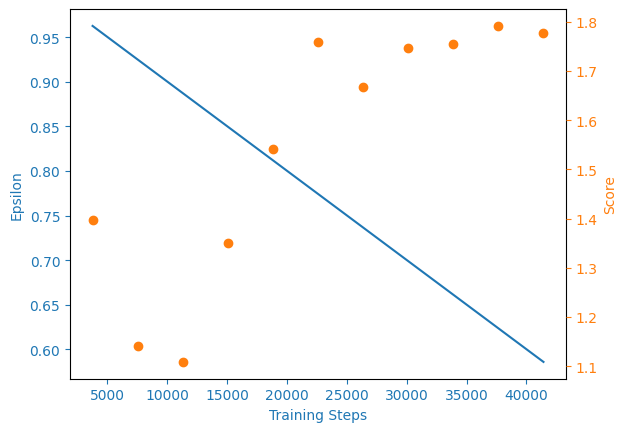

In [20]:

x = [i+1 for i in range(len(scores))]
plot_learning_curve(steps_array, scores, eps_history, figure_file)